In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [37]:
data = {
    "Date": [
        "2026-01-05", "2026-01-10", "2026-01-15",
        "2026-02-05", "2026-02-12", "2026-02-20",
        "2026-03-04", "2026-03-11", "2026-03-18",
        "2026-04-05", "2026-04-15", "2026-04-25"
    ],

    "Amount": [
        1200, 500, 2000,
        800, 1500, 600,
        2200, 900, 700,
        1300, 450, 1800
    ],

    "Category": [
        "Food", "Transport", "Utilities",
        "Entertainment", "Food", "Transport",
        "Utilities", "Entertainment", "Food",
        "Transport", "Entertainment", "Utilities"
    ],

    "Description": [
        "Groceries", "Bus", "Electricity Bill",
        "Movie", "Restaurant", "Cab",
        "Electricity Bill", "Shopping", "Groceries",
        "Fuel", "Movie", "Internet Bill"
    ]
}

df = pd.DataFrame(data)

print(df)

          Date  Amount       Category       Description
0   2026-01-05    1200           Food         Groceries
1   2026-01-10     500      Transport               Bus
2   2026-01-15    2000      Utilities  Electricity Bill
3   2026-02-05     800  Entertainment             Movie
4   2026-02-12    1500           Food        Restaurant
5   2026-02-20     600      Transport               Cab
6   2026-03-04    2200      Utilities  Electricity Bill
7   2026-03-11     900  Entertainment          Shopping
8   2026-03-18     700           Food         Groceries
9   2026-04-05    1300      Transport              Fuel
10  2026-04-15     450  Entertainment             Movie
11  2026-04-25    1800      Utilities     Internet Bill


In [39]:
df.to_csv("expense.csv", index=False)

print("expense.csv created successfully")

expense.csv created successfully


In [40]:
df = pd.read_csv("expense.csv")

print(df)

          Date  Amount       Category       Description
0   2026-01-05    1200           Food         Groceries
1   2026-01-10     500      Transport               Bus
2   2026-01-15    2000      Utilities  Electricity Bill
3   2026-02-05     800  Entertainment             Movie
4   2026-02-12    1500           Food        Restaurant
5   2026-02-20     600      Transport               Cab
6   2026-03-04    2200      Utilities  Electricity Bill
7   2026-03-11     900  Entertainment          Shopping
8   2026-03-18     700           Food         Groceries
9   2026-04-05    1300      Transport              Fuel
10  2026-04-15     450  Entertainment             Movie
11  2026-04-25    1800      Utilities     Internet Bill


In [7]:
df.head()

,Date,Amount,Category,Description
0,2026-01-02,1200,Food,Groceries
1,2026-01-05,500,Transport,Bus and Auto
2,2026-01-10,2200,Utilities,Electricity Bill
3,2026-01-15,800,Entertainment,Movie
4,2026-02-02,1500,Food,Restaurant


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         20 non-null     str  
 1   Amount       20 non-null     int64
 2   Category     20 non-null     str  
 3   Description  20 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.3 KB


In [9]:
df.describe()

,Amount
count,20.000000
mean,1275.000000
std,683.162152
min,450.000000
25%,775.000000
50%,1050.000000
75%,1725.000000
max,2500.000000


In [41]:
print(df.isnull().sum())

Date           0
Amount         0
Category       0
Description    0
dtype: int64


In [42]:
# Remove missing values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert Date into date format
df["Date"] = pd.to_datetime(df["Date"])

print(df)

         Date  Amount       Category       Description
0  2026-01-05    1200           Food         Groceries
1  2026-01-10     500      Transport               Bus
2  2026-01-15    2000      Utilities  Electricity Bill
3  2026-02-05     800  Entertainment             Movie
4  2026-02-12    1500           Food        Restaurant
5  2026-02-20     600      Transport               Cab
6  2026-03-04    2200      Utilities  Electricity Bill
7  2026-03-11     900  Entertainment          Shopping
8  2026-03-18     700           Food         Groceries
9  2026-04-05    1300      Transport              Fuel
10 2026-04-15     450  Entertainment             Movie
11 2026-04-25    1800      Utilities     Internet Bill


In [43]:
categories = ["Food", "Transport", "Utilities", "Entertainment"]

amount = 500
category = "Food"

if amount <= 0:
    print("Amount must be positive")

elif category not in categories:
    print("Invalid category")

else:
    print("Valid Expense")

Valid Expense


In [44]:
class ExpenseTracker:

    def __init__(self, data):
        self.data = data

    def add_expense(self, date, amount, category, description):

        if amount <= 0:
            print("Amount must be positive")
            return

        new_data = {
            "Date": pd.to_datetime(date),
            "Amount": amount,
            "Category": category,
            "Description": description
        }

        self.data.loc[len(self.data)] = new_data

        print("Expense added successfully")

    def get_summary(self):

        print("Total Expense:", self.data["Amount"].sum())
        print("Average Expense:", self.data["Amount"].mean())

    def filter_expenses(self, category):

        result = self.data[self.data["Category"] == category]

        return result

    def generate_report(self):

        print("----- Expense Report -----")

        print("Total:", self.data["Amount"].sum())
        print("Average:", self.data["Amount"].mean())
        print("Maximum:", self.data["Amount"].max())
        print("Minimum:", self.data["Amount"].min())

In [45]:
tracker = ExpenseTracker(df)

print("Expense Tracker created successfully!")

Expense Tracker created successfully!


In [17]:
tracker.add_expense("2026-06-01", 750, "Food", "Dinner")

Expense added successfully!


In [18]:
tracker.get_summary()

----- Expense Summary -----
Total Expense: 27000
Average Expense: 1227.27

Category-wise Expense:
Category
Entertainment     4500
Food              8200
Transport         2800
Utilities        11500
Name: Amount, dtype: int64


In [46]:
food_data = tracker.filter_expenses("Food")
print(food_data)

        Date  Amount Category Description
0 2026-01-05    1200     Food   Groceries
4 2026-02-12    1500     Food  Restaurant
8 2026-03-18     700     Food   Groceries


In [21]:
tracker.generate_report()

========== EXPENSE REPORT ==========
Total Expenses: 27000
Average Expense: 1227.27
Maximum Expense: 2500
Minimum Expense: 450

Category-wise Spending:
Category
Entertainment     4500
Food              8200
Transport         2800
Utilities        11500
Name: Amount, dtype: int64


In [23]:
import numpy as np

In [47]:
amounts = np.array(df["Amount"])

print("Amounts:", amounts)

print("Total:", np.sum(amounts))
print("Average:", np.mean(amounts))
print("Maximum:", np.max(amounts))
print("Minimum:", np.min(amounts))

Amounts: [1200  500 2000  800 1500  600 2200  900  700 1300  450 1800]
Total: 13950
Average: 1162.5
Maximum: 2200
Minimum: 450


In [49]:
category_total = df.groupby("Category") ["Amount"].sum()

print(category_total)

Category
Entertainment    2150
Food             3400
Transport        2400
Utilities        6000
Name: Amount, dtype: int64


In [55]:
category_total = df.groupby("Category")["Amount"].sum()

print("Highest Spending Category:")
print(category_total.idxmax())

print("Highest Spending Amount:")
print(category_total.max())

Highest Spending Category:
Utilities
Highest Spending Amount:
6000


In [56]:
df["Month"] = df["Date"].dt.month_name()

monthly_total = df.groupby("Month")["Amount"].sum()

print(monthly_total)

Month
April       3550
February    2900
January     3700
March       3800
Name: Amount, dtype: int64


In [61]:
category_total = df.groupby("Category")["Amount"].sum()

percentage = (category_total / df["Amount"].sum())*100

print(percentage)

Category
Entertainment    15.412186
Food             24.372760
Transport        17.204301
Utilities        43.010753
Name: Amount, dtype: float64


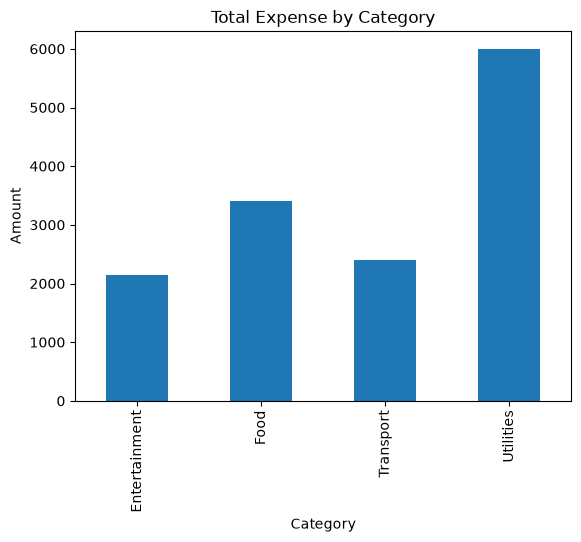

In [62]:
category_total = df.groupby ("Category")["Amount"].sum()

category_total.plot(kind="bar")

plt.title("Total Expense by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.show()

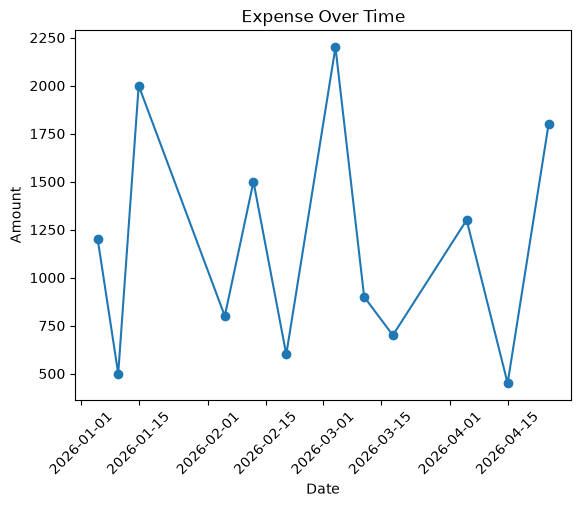

In [64]:
plt.plot(df["Date"], df["Amount"], marker='o')

plt.title("Expense Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.show()

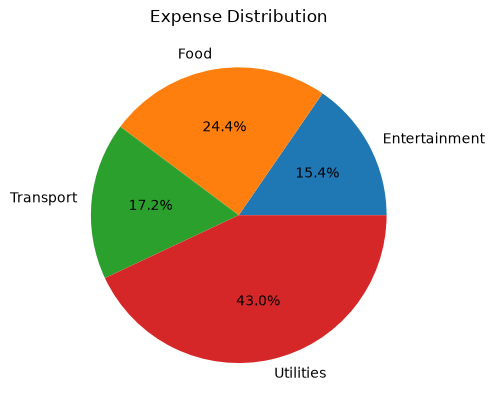

In [65]:
category_total = df.groupby("Category")["Amount"].sum()

plt.pie(
    category_total,
    labels=category_total.index,
    autopct="%1.1f%%"
)

plt.title("Expense Distribution")

plt.show()

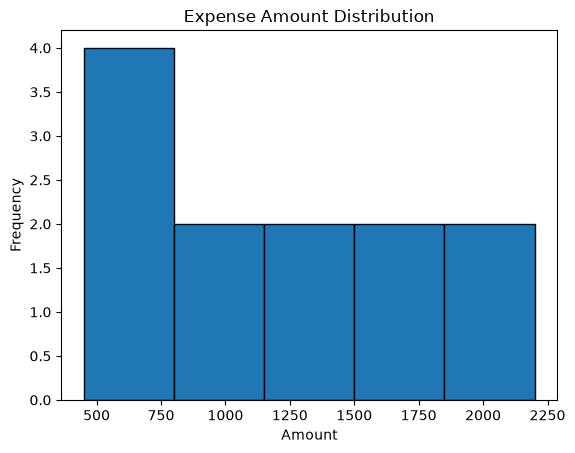

In [66]:
plt.hist(
    df["Amount"],
    bins=5,
    edgecolor="black"
)

plt.title("Expense Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

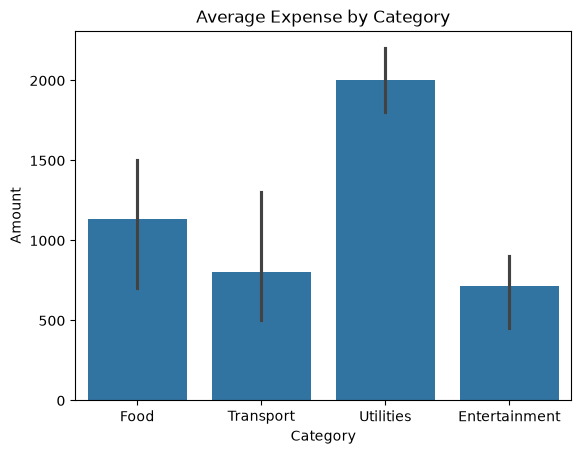

In [67]:
sns.barplot(
    data=df,
    x="Category",
    y="Amount"
)

plt.title("Average Expense by Category")

plt.show()

In [68]:
start_date = "2026-02-01"
end_date = "2026-03-31"

result = df[
    (df["Date"] >= start_date) &
    (df["Date"] <= end_date)
]

print(result)

        Date  Amount       Category       Description     Month
3 2026-02-05     800  Entertainment             Movie  February
4 2026-02-12    1500           Food        Restaurant  February
5 2026-02-20     600      Transport               Cab  February
6 2026-03-04    2200      Utilities  Electricity Bill     March
7 2026-03-11     900  Entertainment          Shopping     March
8 2026-03-18     700           Food         Groceries     March


In [70]:
date = input("Enter date (YYYY-MM-DD): ")

amount = float(input("Enter amount: "))

category = input("Enter category: ")

description = input("Enter description: ")

if amount > 0:

    tracker.add_expense(date,amount,category,description)
        

else:
    print("Amount must be positive")

Expense added successfully


In [73]:
while True:

    print("\n--- SMART EXPENSE TRACKER ---")

    print("1. Add Expense")
    print("2. View Summary")
    print("3. Filter Expense")
    print("4. Generate Report")
    print("5. View Data")
    print("6. Exit")

    choice = input("Enter your choice: ")

    if choice == "1":

        date = input("Enter date: ")
        amount = float(input("Enter amount: "))
        category = input("Enter category: ")
        description = input("Enter description: ")

        tracker.add_expense(date,amount,category,description)

    elif choice == "2":

        tracker.get_summary()

    elif choice == "3":

        category = input("Enter category: ")

        print(tracker.filter_expenses(category))

    elif choice == "4":

        tracker.generate_report()

    elif choice == "5":

        print(tracker.data)

    elif choice == "6":

        print("Thank you!")
        break

    else:

        print("Invalid choice")


--- SMART EXPENSE TRACKER ---
1. Add Expense
2. View Summary
3. Filter Expense
4. Generate Report
5. View Data
6. Exit
Invalid choice

--- SMART EXPENSE TRACKER ---
1. Add Expense
2. View Summary
3. Filter Expense
4. Generate Report
5. View Data
6. Exit
Total Expense: 16684.0
Average Expense: 1191.7142857142858

--- SMART EXPENSE TRACKER ---
1. Add Expense
2. View Summary
3. Filter Expense
4. Generate Report
5. View Data
6. Exit
Empty DataFrame
Columns: [Date, Amount, Category, Description, Month]
Index: []

--- SMART EXPENSE TRACKER ---
1. Add Expense
2. View Summary
3. Filter Expense
4. Generate Report
5. View Data
6. Exit
         Date  Amount       Category       Description     Month
0  2026-01-05  1200.0           Food         Groceries   January
1  2026-01-10   500.0      Transport               Bus   January
2  2026-01-15  2000.0      Utilities  Electricity Bill   January
3  2026-02-05   800.0  Entertainment             Movie  February
4  2026-02-12  1500.0           Food     